In [15]:
from sklearn.linear_model import  Lasso
import pandas as pd 
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [12]:
insaurance_data = pd.read_csv("insurance.csv")

X = insaurance_data.drop(columns = ["charges"])
y = insaurance_data['charges']

X = pd.get_dummies(X, columns= ["region"],drop_first=True, dtype = int)

X["sex"] =  X["sex"].map({"female":1,"male":0})
X["smoker"] =  X["smoker"].map({"yes":1,"no":0})
X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


MSE for alpha = 0.001 : 20922599.871035952
MSE for alpha = 1e-07 : 20922607.937263887
MSE for alpha = 0.2 : 20921006.72913666
MSE for alpha = 2.4 : 20905669.75608251
MSE for alpha = 5 : 20890881.000633497
MSE for alpha = 10 : 20872844.794796687
MSE for alpha = 20 : 20877828.532378826
MSE for alpha = 30 : 20937537.133939773
MSE for alpha = 40 : 21046489.293890774
MSE for alpha = 50 : 21196929.86960891
MSE for alpha = 100 : 22423172.68602325


<Axes: >

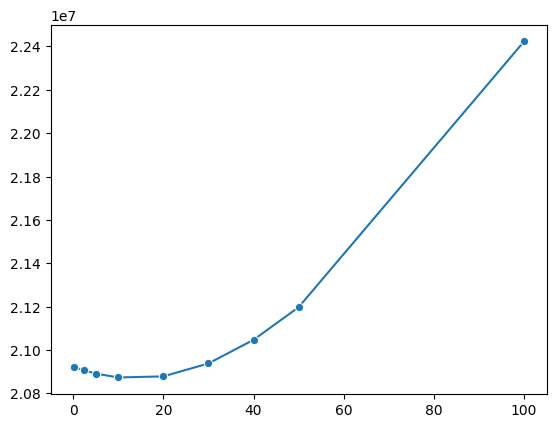

In [31]:
alphas = [0.001,0.0000001,0.2,2.4,5,10,20,30,40,50,100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train,y_train)
    
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    
    print(f"MSE for alpha = {a} :", mse)
    mses.append(mse)
import seaborn as sns
sns.lineplot(x =alphas, y=mses, marker="o") 

In [33]:
from sklearn.linear_model import  LassoCV 

a = [0.001,0.0001,0.2,2.4,5,10,20,30,40,50,100]

lasso_cv_model = LassoCV(
    alphas = a,
    cv=5,
    max_iter = 1000,
    random_state=42
)

lasso_cv_model.fit(X_train,y_train)
print("best alpha :" , lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("mse : " , mse)

best alpha : 0.0001
mse :  20922607.131011523
